In [ ]:
#You are part of a global health task force investigating whether dietary sugar intake is associated with higher obesity rates across countries. Using data from 25 nations, you’ll conduct a hypothesis test, build a regression model, and visualize your findings.

In [4]:
#Importing Libraries
library("tidyverse")
library(ggplot2)

In [11]:
#Importing dataset
data <- read.csv("sdg3_sugar_obesity_data.csv")
glimpse(data) 

Rows: 25
Columns: 3
$ Country                <chr> "Australia", "Brazil", "Canada", "China", "Fran…
$ Sugar_Intake_g_per_day <dbl> 81.3, 85.7, 42.3, 53.7, 94.8, 106.7, 64.6, 111.…
$ Obesity_Rate_percent   <dbl> 28.5, 31.0, 22.7, 21.5, 37.5, 37.8, 20.6, 45.3,…


In [12]:
#Viewing dataset
head(data)

,Country,Sugar_Intake_g_per_day,Obesity_Rate_percent
,<chr>,<dbl>,<dbl>
1,Australia,81.3,28.5
2,Brazil,85.7,31.0
3,Canada,42.3,22.7
4,China,53.7,21.5
5,France,94.8,37.5
6,Germany,106.7,37.8


In [13]:
#Step 1 Exploring the Data
summary(data)

   Country          Sugar_Intake_g_per_day Obesity_Rate_percent
 Length:25          Min.   : 42.30         Min.   :12.40       
 Class :character   1st Qu.: 55.00         1st Qu.:20.60       
 Mode  :character   Median : 81.30         Median :24.90       
                    Mean   : 76.03         Mean   :28.04       
                    3rd Qu.: 94.80         3rd Qu.:37.00       
                    Max.   :117.20         Max.   :45.30       

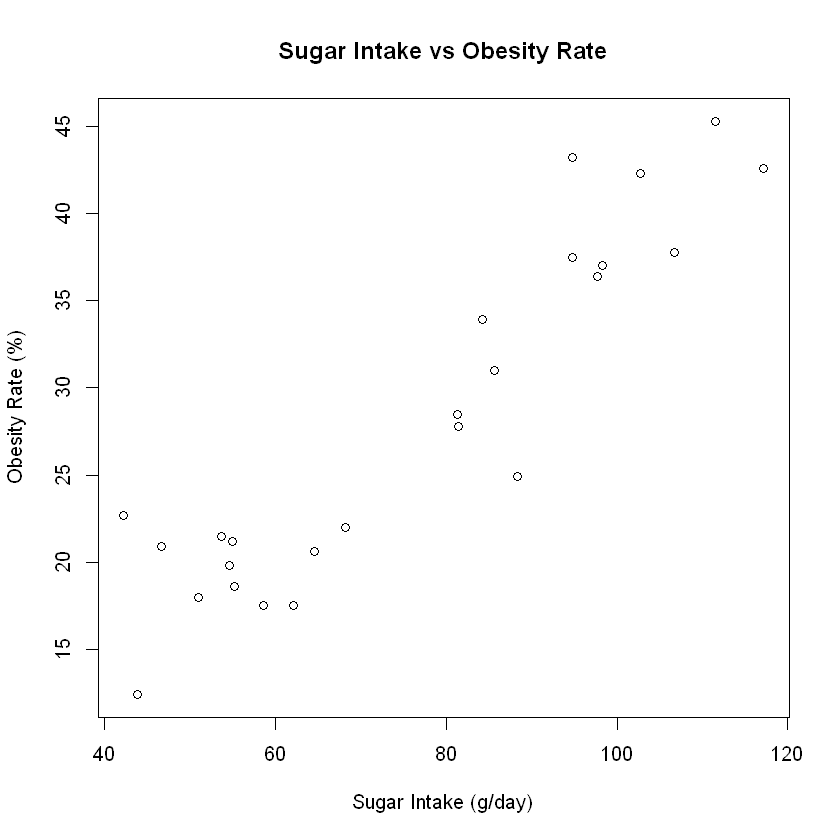

In [14]:
plot(data$Sugar_Intake_g_per_day, data$Obesity_Rate_percent,
     main = "Sugar Intake vs Obesity Rate",
     xlab = "Sugar Intake (g/day)",
     ylab = "Obesity Rate (%)")

#data$Sugar_Intake_g_per_day is the X-axis values
#data$Obesity_Rate_percent is the Y-axis values


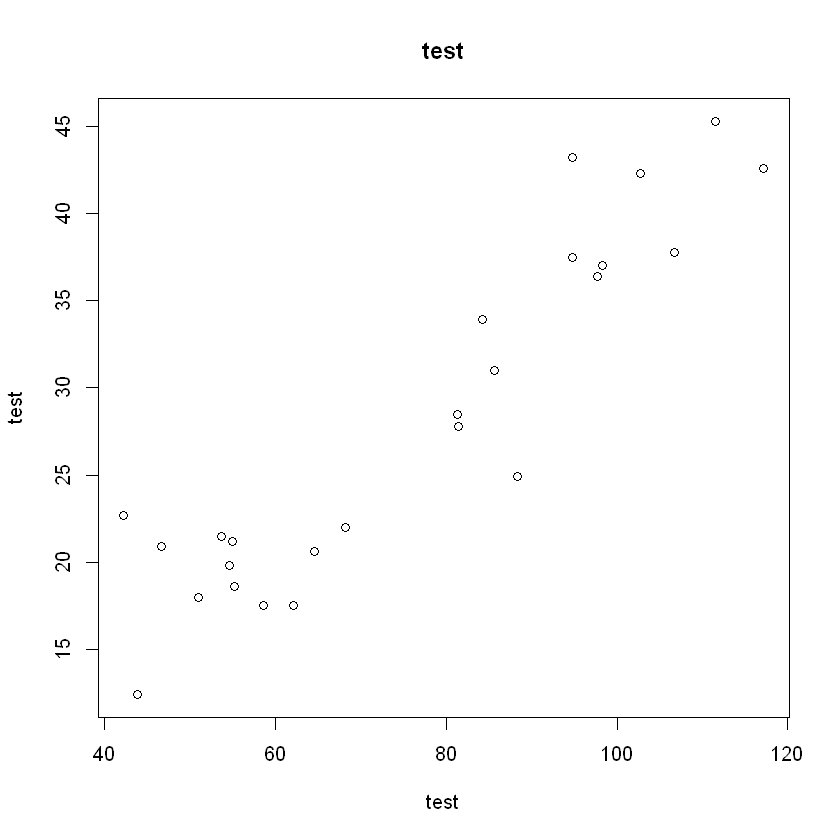

In [15]:
#Prompt:  Change the axis labels or title and observe the output.
plot(data$Sugar_Intake_g_per_day, data$Obesity_Rate_percent,
     main = "test",
     xlab = "test",
     ylab = "test")

In [16]:
#Step 2 - Hypothesis test
#Test whether countries with above-average sugar intake have significantly different obesity rates.

# Create groups
avg_sugar <- mean(data$Sugar_Intake_g_per_day)
data$Group <- ifelse(data$Sugar_Intake_g_per_day > avg_sugar, "High", "Low")

# Run t-test
t.test(Obesity_Rate_percent ~ Group, data = data)


	Welch Two Sample t-test

data:  Obesity_Rate_percent by Group
t = 8.4184, df = 16.684, p-value = 2.084e-07
alternative hypothesis: true difference in means between group High and group Low is not equal to 0
95 percent confidence interval:
 12.45148 20.79595
sample estimates:
mean in group High  mean in group Low 
          36.01538           19.39167 


In [17]:
#Replacing "High" with "Above Avg"
# Create groups
avg_sugar <- mean(data$Sugar_Intake_g_per_day)
data$Group <- ifelse(data$Sugar_Intake_g_per_day > avg_sugar, "Above Avg", "Low")

# Run t-test
t.test(Obesity_Rate_percent ~ Group, data = data)


	Welch Two Sample t-test

data:  Obesity_Rate_percent by Group
t = 8.4184, df = 16.684, p-value = 2.084e-07
alternative hypothesis: true difference in means between group Above Avg and group Low is not equal to 0
95 percent confidence interval:
 12.45148 20.79595
sample estimates:
mean in group Above Avg       mean in group Low 
               36.01538                19.39167 


In [ ]:
#No difference in grouping.

In [18]:
#Step 3 Building the Regression Model
model <- lm(Obesity_Rate_percent ~ Sugar_Intake_g_per_day, data = data)
summary(model)


Call:
lm(formula = Obesity_Rate_percent ~ Sugar_Intake_g_per_day, data = data)

Residuals:
    Min      1Q  Median      3Q     Max 
-7.9611 -2.3481 -0.1956  2.2429  7.9251 

Coefficients:
                       Estimate Std. Error t value Pr(>|t|)    
(Intercept)            -1.85648    2.66618  -0.696    0.493    
Sugar_Intake_g_per_day  0.39318    0.03361  11.699 3.66e-11 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 3.807 on 23 degrees of freedom
Multiple R-squared:  0.8561,	Adjusted R-squared:  0.8499 
F-statistic: 136.9 on 1 and 23 DF,  p-value: 3.664e-11


In [26]:
slope <- 0.39318
#The slope suggests that sugar predicts a upwards trend 
p_value <- 0.00000000003664
#E.g If sugar intake had NO effect on obesity at all, how likely is it that I would still get results like these just by random chance?
#The relationship to the hypothesis of sugar predicting obesity is significant. It is less than 0.05.
r_squared <- 0.8499
#85% of sugar explains the variation in obesity rates

`geom_smooth()` using formula = 'y ~ x'


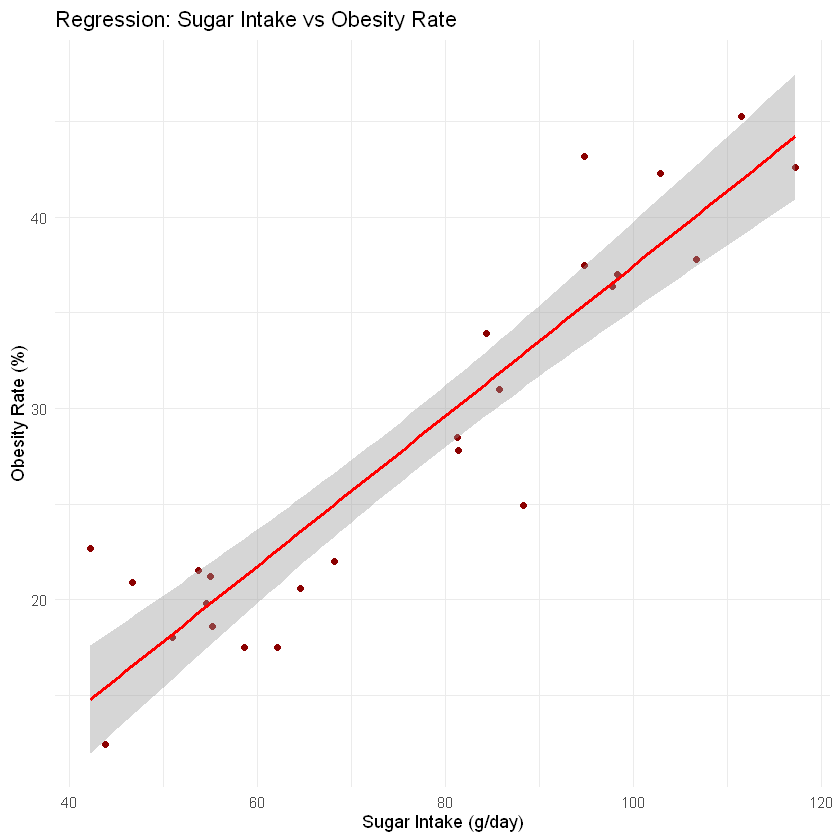

In [27]:
#Step 3 Visualise the Model
library(ggplot2)

ggplot(data, aes(x = Sugar_Intake_g_per_day, y = Obesity_Rate_percent)) +
  geom_point(color = "darkred") +
  geom_smooth(method = "lm", se = TRUE, color = "red") +
  labs(
    title = "Regression: Sugar Intake vs Obesity Rate",
    x = "Sugar Intake (g/day)",
    y = "Obesity Rate (%)"
  ) +
  theme_minimal()

`geom_smooth()` using formula = 'y ~ x'


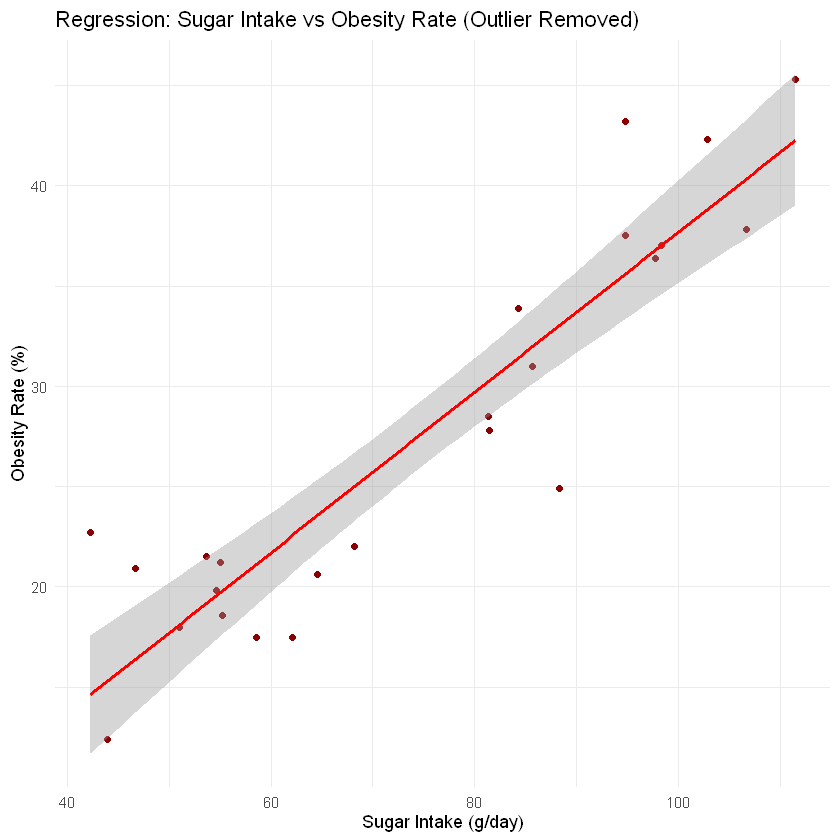

In [28]:
#Step 5 - Trying Variations

#Removing the outlier of the country with the highest sugar intake
outlier <- data[data$Sugar_Intake_g_per_day != max(data$Sugar_Intake_g_per_day),]
#Goes through every row checking if the row's intake value NOT equal to max. value and returns only the values that are.

#Visualising the new model
library(ggplot2)
ggplot(outlier, aes(x = Sugar_Intake_g_per_day, y = Obesity_Rate_percent)) +
  geom_point(color = "darkred") +
  geom_smooth(method = "lm", se = TRUE, color = "red") +
  labs(
    title = "Regression: Sugar Intake vs Obesity Rate (Outlier Removed)",
    x = "Sugar Intake (g/day)",
    y = "Obesity Rate (%)"
  ) +
  theme_minimal()


In [29]:
#Checking R-squared variation in outlier dataset
model_2 <- lm(Obesity_Rate_percent ~ Sugar_Intake_g_per_day, data = outlier)
summary(model_2)


Call:
lm(formula = Obesity_Rate_percent ~ Sugar_Intake_g_per_day, data = outlier)

Residuals:
    Min      1Q  Median      3Q     Max 
-8.1168 -2.6454 -0.2441  2.3490  8.0589 

Coefficients:
                       Estimate Std. Error t value Pr(>|t|)    
(Intercept)            -2.25657    2.84864  -0.792    0.437    
Sugar_Intake_g_per_day  0.39947    0.03683  10.847 2.69e-10 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 3.874 on 22 degrees of freedom
Multiple R-squared:  0.8425,	Adjusted R-squared:  0.8353 
F-statistic: 117.7 on 1 and 22 DF,  p-value: 2.694e-10


In [30]:
r_squared_2 <- 0.8353
print(r_squared)
print(r_squared_2)

#Increasing sugar variability actually lowered the R_squared value by 1%.

[1] 0.8499
[1] 0.8353
